In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('Netflix business case study/netflix.csv')


In [4]:
'''Finding number of null values'''
data.isnull().sum(axis = 0)

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
#replacing nullvalues'''
data.fillna({'country':'unknown','date_added':'unknown','director':'unknown','cast':'unkown','rating':0,'duration':'unkown'},inplace = True)

In [9]:
'''Here I have created a function which will take the dataframe name as dataset,column which user wants to explode as column '''
def split_exp(dataset,column):
    df = dataset.copy()
    df[column] = df[column].str.split(',')
    df = df.explode(column,ignore_index = True)
    return df

    
    

In [5]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
'''I am creating a copy of the dataset so that no changes happen in the original data.'''
df = data.copy()

In [7]:
'''I will now split and explode the cast column in the df'''
df = split_exp(dataset = df,column = 'cast')

In [8]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s2,TV Show,Blood & Water,NaN,Khosi Ngema,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,s2,TV Show,Blood & Water,NaN,Gail Mabalane,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
4,s2,TV Show,Blood & Water,NaN,Thabang Molaba,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [9]:
'''Now we will check for the missing values in the dataset'''
df.isna().sum(axis = 0)
'''We can see that there are multiple null values in director,cast,country,date_added,rating,duration
   '''



'We can see that there are multiple null values in director,cast,country,date_added,rating,duration\n   '

In [10]:
'''We will replace null values of director,cast,country,date_added with unknown and rating and duration with 0'''
df.fillna({'director':'unknown','cast':'unknown','country':'unknown','date_added':'unknown','rating':0,'duration':0},inplace = True)

In [11]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,Ama Qamata,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s2,TV Show,Blood & Water,unknown,Khosi Ngema,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,s2,TV Show,Blood & Water,unknown,Gail Mabalane,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
4,s2,TV Show,Blood & Water,unknown,Thabang Molaba,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [12]:
df['release_year'].head()

0    2020
1    2021
2    2021
3    2021
4    2021
Name: release_year, dtype: int64

In [13]:
'''How has the number of movies released per year changed over the last 20-30 years?'''
'''To answer this question we need to get the unique titles released each year and we will assign that dataframe to variable a'''
a = df[(df['release_year']>1990)&(df['release_year']<2025)]
a = a.groupby('release_year')['title'].nunique().reset_index()

In [14]:
a.head

<bound method NDFrame.head of     release_year  title
0           1991     17
1           1992     23
2           1993     28
3           1994     22
4           1995     25
5           1996     24
6           1997     38
7           1998     36
8           1999     39
9           2000     37
10          2001     45
11          2002     51
12          2003     61
13          2004     64
14          2005     80
15          2006     96
16          2007     88
17          2008    136
18          2009    152
19          2010    194
20          2011    185
21          2012    237
22          2013    288
23          2014    352
24          2015    560
25          2016    902
26          2017   1032
27          2018   1147
28          2019   1030
29          2020    953
30          2021    592>

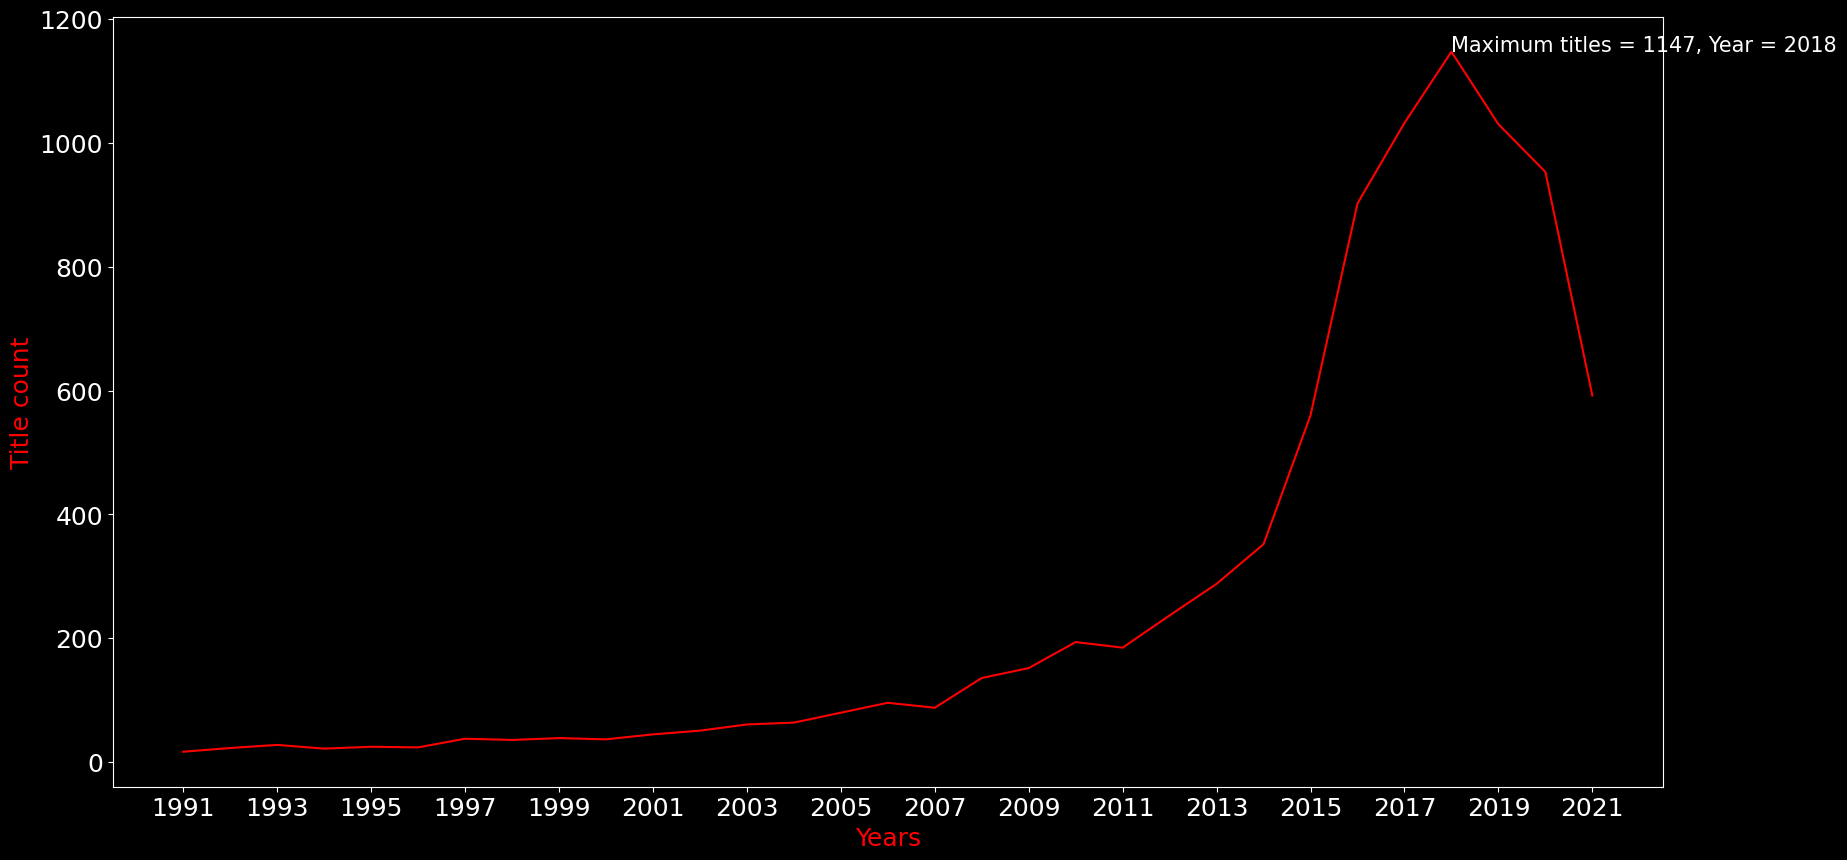

'Insights from this chart have been presented in a well articulated manner in the project pdf'

In [240]:
'''Best way to represent titles released each year is by line plot'''
plt.figure(figsize = (20,10))
plt.style.use('dark_background')
sns.lineplot(data = a,x = 'release_year',y = 'title',color = 'red')
start,end = a['release_year'].min(),a['release_year'].max()
plt.xticks(np.arange(start,end+1,2),color = 'white',fontsize = 18)
plt.yticks(color = 'white',fontsize = 18)
plt.xlabel('Years',fontsize = 18,color = 'red')
plt.ylabel('Title count',fontsize = 18,color = 'red')
plt.text(x = 2018,y = 1147,s = 'Maximum titles = 1147, Year = 2018',color = 'white',fontsize = 15)
plt.show()
'''Insights from this chart have been presented in a well articulated manner in the project pdf'''

In [16]:
'''Q) What type of content is available in different countries?'''
'''Approach: Since there are 748 unique countries it would not be feasible to represent the data of all 748 for analysis hence we will take top 10
   highest netflix consumer countries to analyse'''
data['country'].nunique()


748

In [17]:
'''top 10 netlfix user countries'''
top10country = data['country'].value_counts().head(10).index

In [18]:
'''This only contains the data corresponding to the top 10 countries from the dataset'''
data_top_country = data[data['country'].isin(top10country)]

In [19]:
data_top_country.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


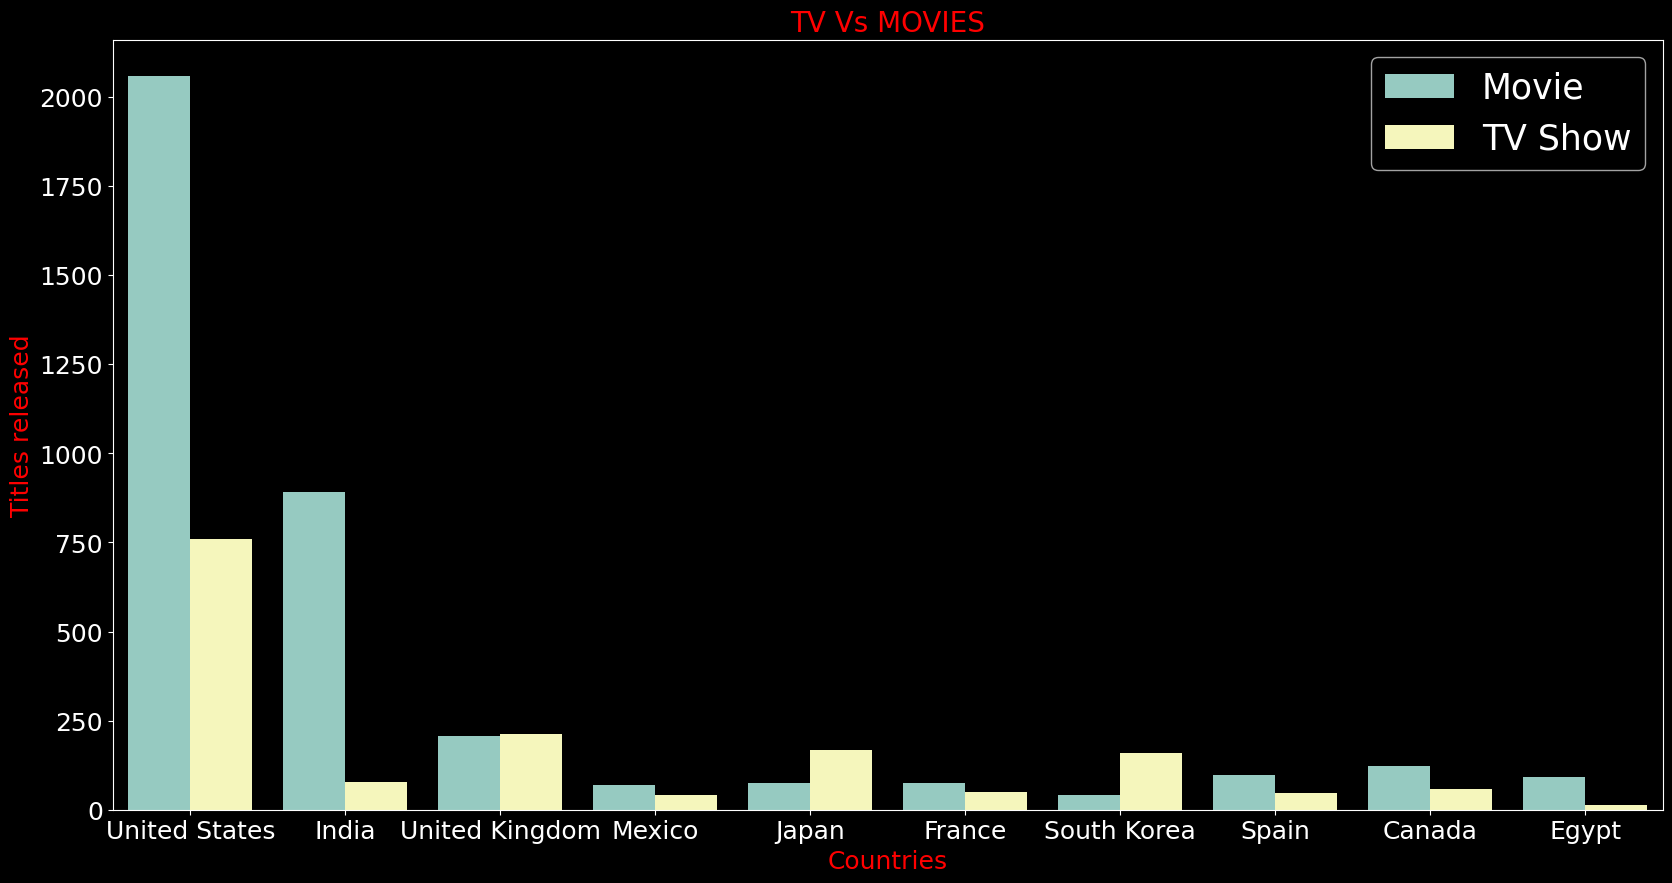

In [241]:
'''Let us find out what is released more on netflix TV shows or Movies'''
'''Since the data which we want to represent in categorical categorical and continuous in nature dodged bar plot or dodged box plot will be good choices'''
plt.figure(figsize = (20,10))
plt.style.use('dark_background')
sns.countplot(data = data_top_country,x = 'country',hue = 'type')
plt.xlabel('Countries',color = 'red',fontsize = 18)
plt.ylabel('Titles released',color = 'red',fontsize = 18)
plt.title('TV Vs MOVIES',color = 'red',fontsize = 20)
plt.legend(labelcolor = 'white',fontsize = 25)
plt.xticks(color = 'white',fontsize = 18)
plt.yticks(color = 'white',fontsize = 18)
plt.show()


In [21]:
'''Here we can see that most of countries have higher number of releases of Movies but in Japan and Korea TV shows are released more than Movies.'''


'Here we can see that most of countries have higher number of releases of Movies but in Japan and Korea TV shows are released more than Movies.'

In [22]:
c = data_top_country.groupby(['country','type']).agg({'type':'count'})

In [23]:
c

type
country        type         
Canada         Movie     122
               TV Show    59
Egypt          Movie      92
               TV Show    14
France         Movie      75
               TV Show    49
India          Movie     893
               TV Show    79
Japan          Movie      76
               TV Show   169
Mexico         Movie      70
               TV Show    40
South Korea    Movie      41
               TV Show   158
Spain          Movie      97
               TV Show    48
United Kingdom Movie     206
               TV Show   213
United States  Movie    2058
               TV Show   760

In [24]:
c.index

MultiIndex([(        'Canada',   'Movie'),
            (        'Canada', 'TV Show'),
            (         'Egypt',   'Movie'),
            (         'Egypt', 'TV Show'),
            (        'France',   'Movie'),
            (        'France', 'TV Show'),
            (         'India',   'Movie'),
            (         'India', 'TV Show'),
            (         'Japan',   'Movie'),
            (         'Japan', 'TV Show'),
            (        'Mexico',   'Movie'),
            (        'Mexico', 'TV Show'),
            (   'South Korea',   'Movie'),
            (   'South Korea', 'TV Show'),
            (         'Spain',   'Movie'),
            (         'Spain', 'TV Show'),
            ('United Kingdom',   'Movie'),
            ('United Kingdom', 'TV Show'),
            ( 'United States',   'Movie'),
            ( 'United States', 'TV Show')],
           names=['country', 'type'])

In [246]:
df1 = pd.DataFrame() # df has been used now for making pie charts and has count of movies and shows by country
df1['count'] = c
df1

count
country        type          
Canada         Movie      122
               TV Show     59
Egypt          Movie       92
               TV Show     14
France         Movie       75
               TV Show     49
India          Movie      893
               TV Show     79
Japan          Movie       76
               TV Show    169
Mexico         Movie       70
               TV Show     40
South Korea    Movie       41
               TV Show    158
Spain          Movie       97
               TV Show     48
United Kingdom Movie      206
               TV Show    213
United States  Movie     2058
               TV Show    760

Text(0.5, 1.0, 'United Kingdom')

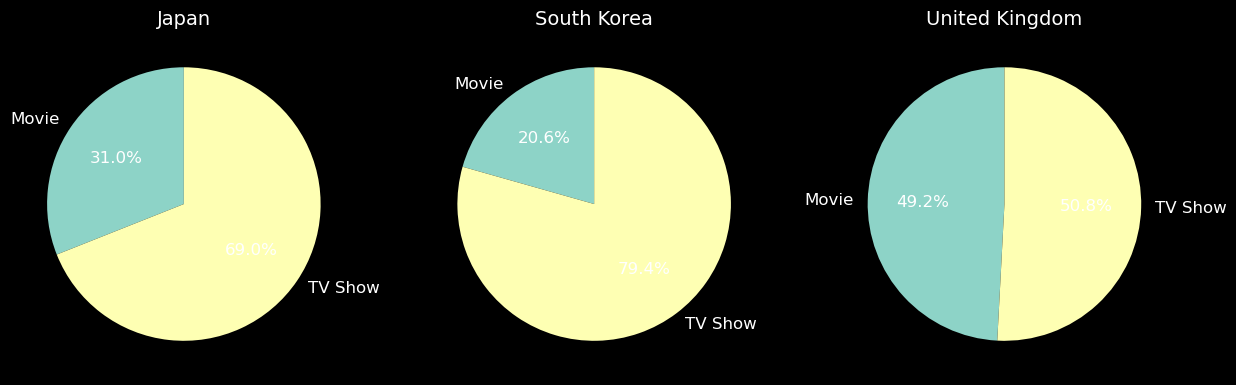

In [247]:

plt.figure(figsize=(15,5))


# Japan
plt.subplot(1,3,1)
plt.pie(
    df1.loc['Japan']['count'],
    labels=df1.loc['Japan']['count'].index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'color':'white', 'fontsize':12})  # this sets label and percentage color together

plt.title('Japan', color='white', fontsize=14)

# South Korea
plt.subplot(1,3,2)
plt.pie(
    df1.loc['South Korea']['count'],
    labels=df1.loc['South Korea']['count'].index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'color':'white', 'fontsize':12})

plt.title('South Korea', color='white', fontsize=14)

# United Kingdom
plt.subplot(1,3,3)
plt.pie(
    df1.loc['United Kingdom']['count'],
    labels=df1.loc['United Kingdom']['count'].index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'color':'white', 'fontsize':12})

plt.title('United Kingdom', color='white', fontsize=14)

In [245]:
'''Now we will see comparative analysis between number of TV shows VS movies being released in the past 30 years''''


SyntaxError: unterminated string literal (detected at line 1) (895024041.py, line 1)

In [60]:
d = data[(data['release_year']>1990) & (data['release_year']<2025)]

In [62]:
d = d.groupby(['release_year','type'])['title'].count() 

In [64]:
d = d.reset_index() 

In [65]:
d.head()

,release_year,type,title
0,1991,Movie,16
1,1991,TV Show,1
2,1992,Movie,20
3,1992,TV Show,3
4,1993,Movie,24


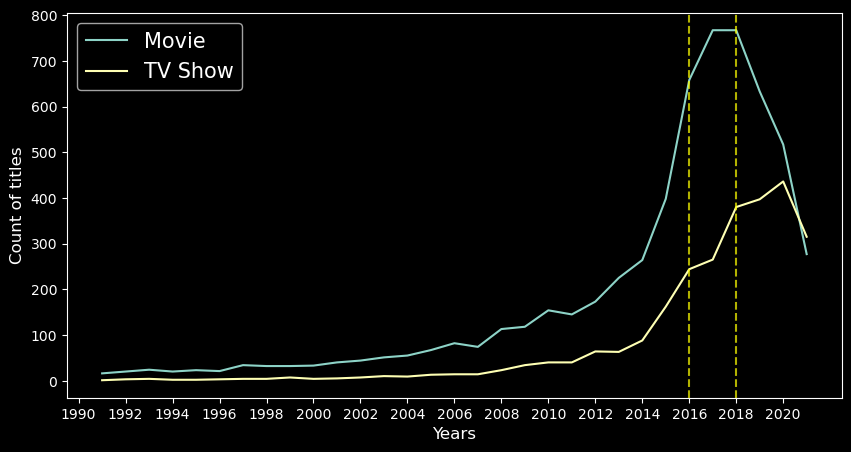

In [94]:
plt.figure(figsize = (10,5))
plt.style.use('dark_background')
sns.lineplot(data = d,x = 'release_year',y = 'title',hue = 'type',color = ['red','white'])
plt.xticks(np.arange(1990,2022,2))
plt.legend(fontsize = 15)
plt.xlabel('Years',fontsize = 12)
plt.ylabel('Count of titles',fontsize = 12)
plt.axvline(x = 2016,linestyle = '--',color = 'yellow',alpha = 0.7)
plt.axvline(x = 2018,linestyle = '--',color = 'yellow',alpha = 0.7)
plt.show()



In [96]:
t = data[data['type'] == 'TV Show']

In [97]:
t.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...


In [108]:
t['duration'].value_counts().values

array([1793,  425,  199,   95,   65,   33,   23,   17,    9,    7,    3,
          2,    2,    2,    1])

Text(0, 0.5, 'Duration')

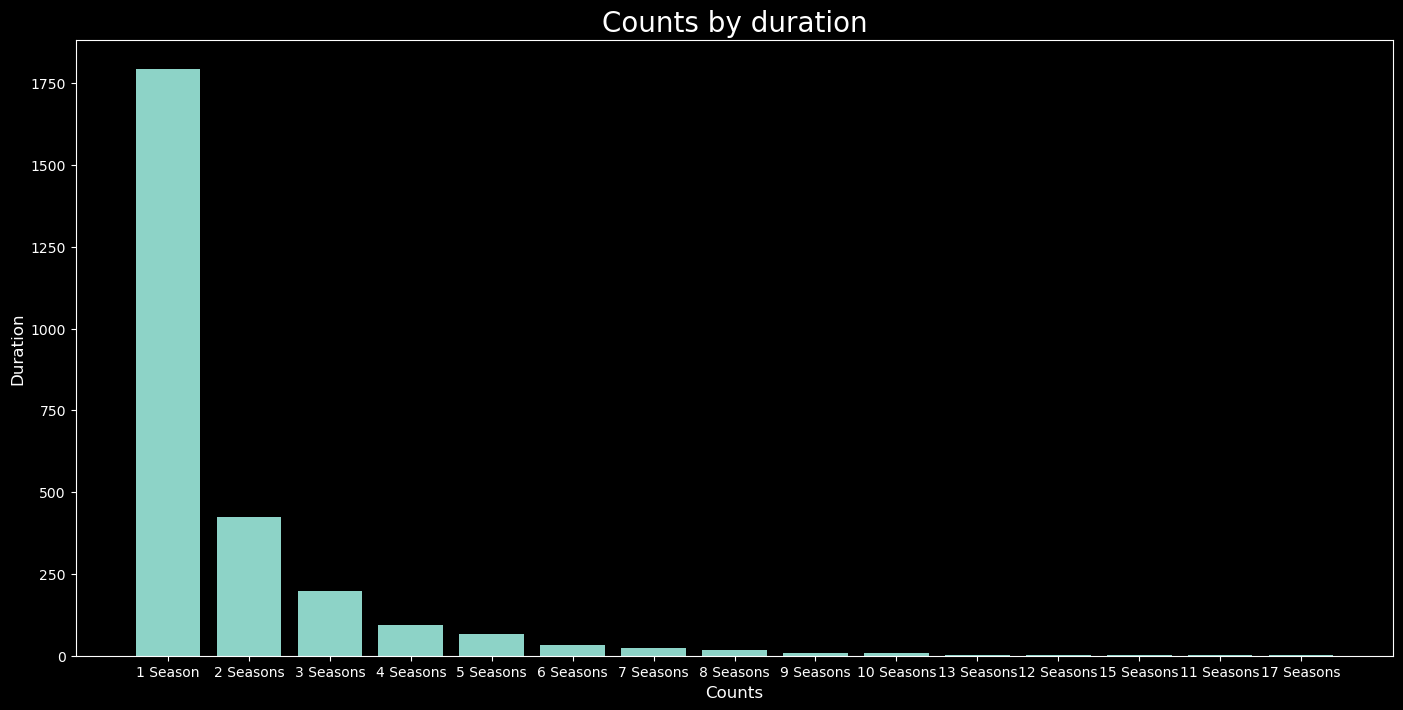

In [119]:
'''We will plot bar plot to check the number of titles as per number of seasons'''
plt.figure(figsize = (17,8))
plt.bar(t['duration'].value_counts().index,t['duration'].value_counts().values)
plt.title('Counts by duration',fontsize = 20,color = 'white')
plt.xlabel('Counts',fontsize = 12,color = 'white')
plt.ylabel('Duration',fontsize = 12,color = 'white')

,release_year,title
0,1991,17
1,1992,23
2,1993,28
3,1994,22
4,1995,25


In [124]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,Ama Qamata,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s2,TV Show,Blood & Water,unknown,Khosi Ngema,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,s2,TV Show,Blood & Water,unknown,Gail Mabalane,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
4,s2,TV Show,Blood & Water,unknown,Thabang Molaba,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [251]:
#We have split the listed_in column to analyse the data on the bases of Genre.
df1 = split_exp(data,'listed_in') 

In [129]:
df1.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."
2,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t..."
3,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t..."
4,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...


In [140]:
df1['listed_in'].value_counts().index[:10]

Index([' International Movies', 'Dramas', 'Comedies', 'Action & Adventure',
       'Documentaries', ' Dramas', 'International TV Shows',
       ' Independent Movies', ' TV Dramas', ' Romantic Movies'],
      dtype='object', name='listed_in')

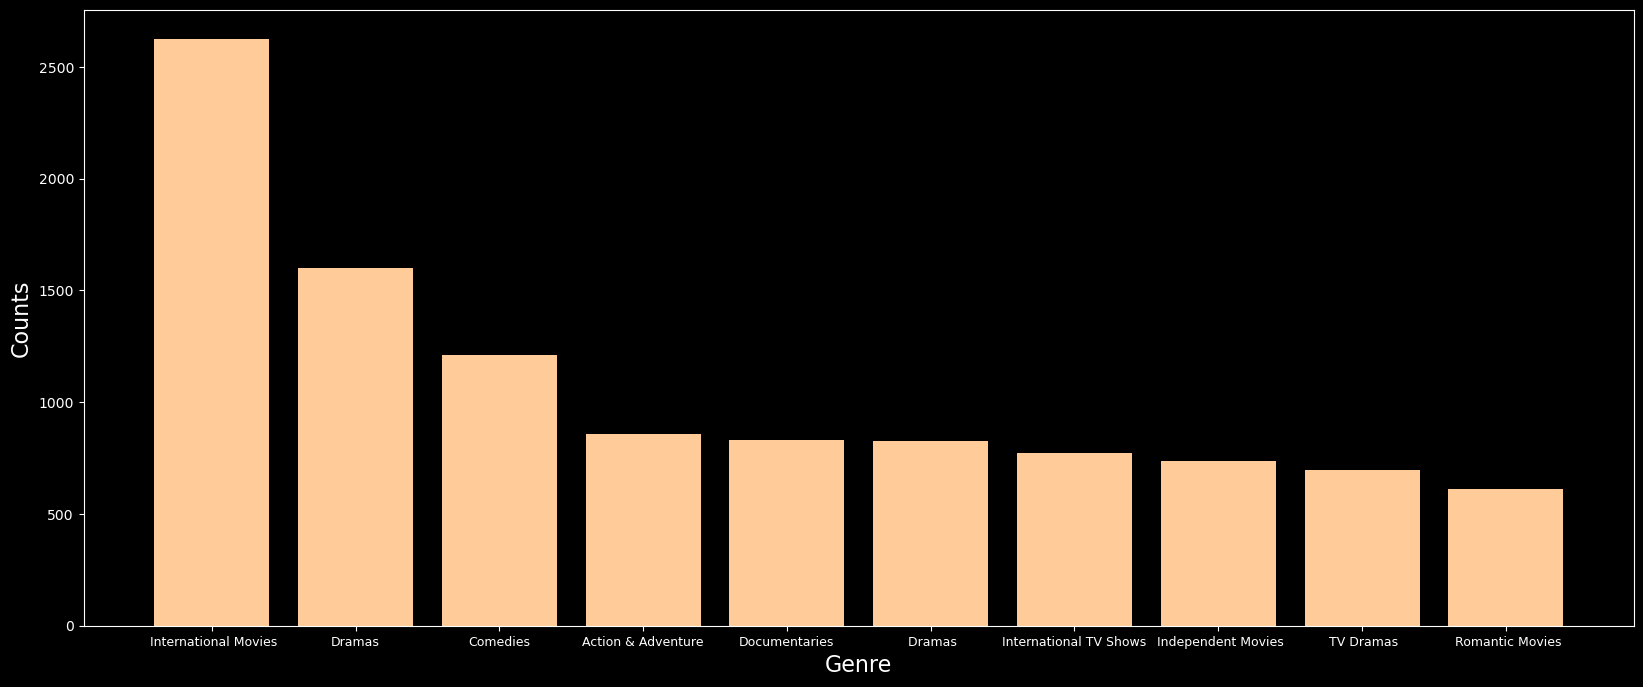

In [164]:
'''This plt tells us the top 10 Genres'''
plt.figure(figsize = (20,8))
plt.bar(df1['listed_in'].value_counts().index[:10],df1['listed_in'].value_counts().values[:10],color = '#FFCC99')
plt.xticks(fontsize = 9)
plt.xlabel('Genre',fontsize = 16)
plt.ylabel('Counts',fontsize = 16)
plt.title
plt.show()

In [165]:
# since it is not feasible to visually represent Genre wise distributon on each country hence we will target Genre wise distribution of top 10 countries
top

show_id  type  title  director  \
country           listed_in                                                
, France, Algeria  Independent Movies           1     1      1         1   
                   International Movies         1     1      1         1   
                  Dramas                        1     1      1         1   
, South Korea      TV Dramas                    1     1      1         0   
                  International TV Shows        1     1      1         0   
...                                           ...   ...    ...       ...   
West Germany       International Movies         1     1      1         1   
                  Documentaries                 1     1      1         1   
Zimbabwe           International Movies         1     1      1         1   
                   Romantic Movies              1     1      1         1   
                  Comedies                      1     1      1         1   

                                          cast  date_added  release_year  \
country           listed_in                                                
, France, Algeria  Independent Movies        1           1             1   
                   International Movies      1           1             1   
                  Dramas                     1           1             1   
, South Korea      TV Dramas                 1           1             1   
                  International TV Shows     1           1             1   
...                                        ...         ...           ...   
West Germany       International Movies      0           1             1   
                  Documentaries              0           1             1   
Zimbabwe           International Movies      1           1             1   
                   Romantic Movies           1           1             1   
                  Comedies                   1           1             1   

                                          rating  duration  description  
country           listed_in                                              
, France, Algeria  Independent Movies          1         1            1  
                   International Movies        1         1            1  
                  Dramas                       1         1            1  
, South Korea      TV Dramas                   1         1            1  
                  International TV Shows       1         1            1  
...                                          ...       ...          ...  
West Germany       International Movies        1         1            1  
                  Documentaries                1         1            1  
Zimbabwe           International Movies        1         1            1  
                   Romantic Movies             1         1            1  
                  Comedies                     1         1            1  

[3278 rows x 10 columns]

In [172]:
data_top_country

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
15,s16,TV Show,Dear White People,NaN,"Logan Browning, Brandon P. Bell, DeRon Horton,...",United States,"September 22, 2021",2021,TV-MA,4 Seasons,"TV Comedies, TV Dramas",Students of color navigate the daily slights a...
...,...,...,...,...,...,...,...,...,...,...,...,...
8799,s8800,Movie,Zenda,Avadhoot Gupte,"Santosh Juvekar, Siddharth Chandekar, Sachit P...",India,"February 15, 2018",2009,TV-14,120 min,"Dramas, International Movies",A change in the leadership of a political part...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [198]:
'''We need top 5 Genres of the top 10 Netflix user countries however it is being very difficult to do it on python hence we will use SQL
and for that we will first get the table with expanded listen in column and will write it to csv and will edit that csv in excel to get the required data'''

In [223]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,Ama Qamata,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s2,TV Show,Blood & Water,unknown,Khosi Ngema,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,s2,TV Show,Blood & Water,unknown,Gail Mabalane,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
4,s2,TV Show,Blood & Water,unknown,Thabang Molaba,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [232]:
df1.to_csv("listedexp.csv",index = False)

In [228]:
data

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [258]:
#data of top 5 countries
df1 = split_exp(data,'listed_in')

In [260]:
df1 = df1[df1['country']!='unknown']

In [261]:
import pandas as pd

#  Get total titles per country 
top5_countries = (
    df1['country']
    .value_counts()
    .head(5)
    .index
)

#  Filter dataset for only those countries 
df_top = df1[df1['country'].isin(top5_countries)]

#  Count unique titles per country-genre combo 
grouped = (
    df_top.groupby(['country', 'listed_in'])['title']
    .nunique()
    .reset_index(name='unique_titles')
)

#  Take top 5 genres *within each country* 
top5_genres = (
    grouped.sort_values(['country', 'unique_titles'], ascending=[True, False])
            .groupby('country')
            .head(5)
)

#  Final result: number of titles in top 5 genres of top 5 countries 
result = top5_genres.sort_values(['country', 'unique_titles'], ascending=[True, False])

print(result)

            country                 listed_in  unique_titles
8             India      International Movies            779
36            India                    Dramas            384
31            India                  Comedies            262
4             India                    Dramas            236
7             India        Independent Movies            149
71            Japan              Anime Series            131
52            Japan    International TV Shows            110
51            Japan      International Movies             55
69            Japan        Action & Adventure             46
45            Japan            Anime Features             39
86      South Korea           Korean TV Shows            130
108     South Korea    International TV Shows            125
91      South Korea         Romantic TV Shows             75
96      South Korea                 TV Dramas             36
84      South Korea      International Movies             33
142  United Kingdom     

In [262]:
result.head()

,country,listed_in,unique_titles
8,India,International Movies,779
36,India,Dramas,384
31,India,Comedies,262
4,India,Dramas,236
7,India,Independent Movies,149


<Axes: xlabel='country', ylabel='unique_titles'>

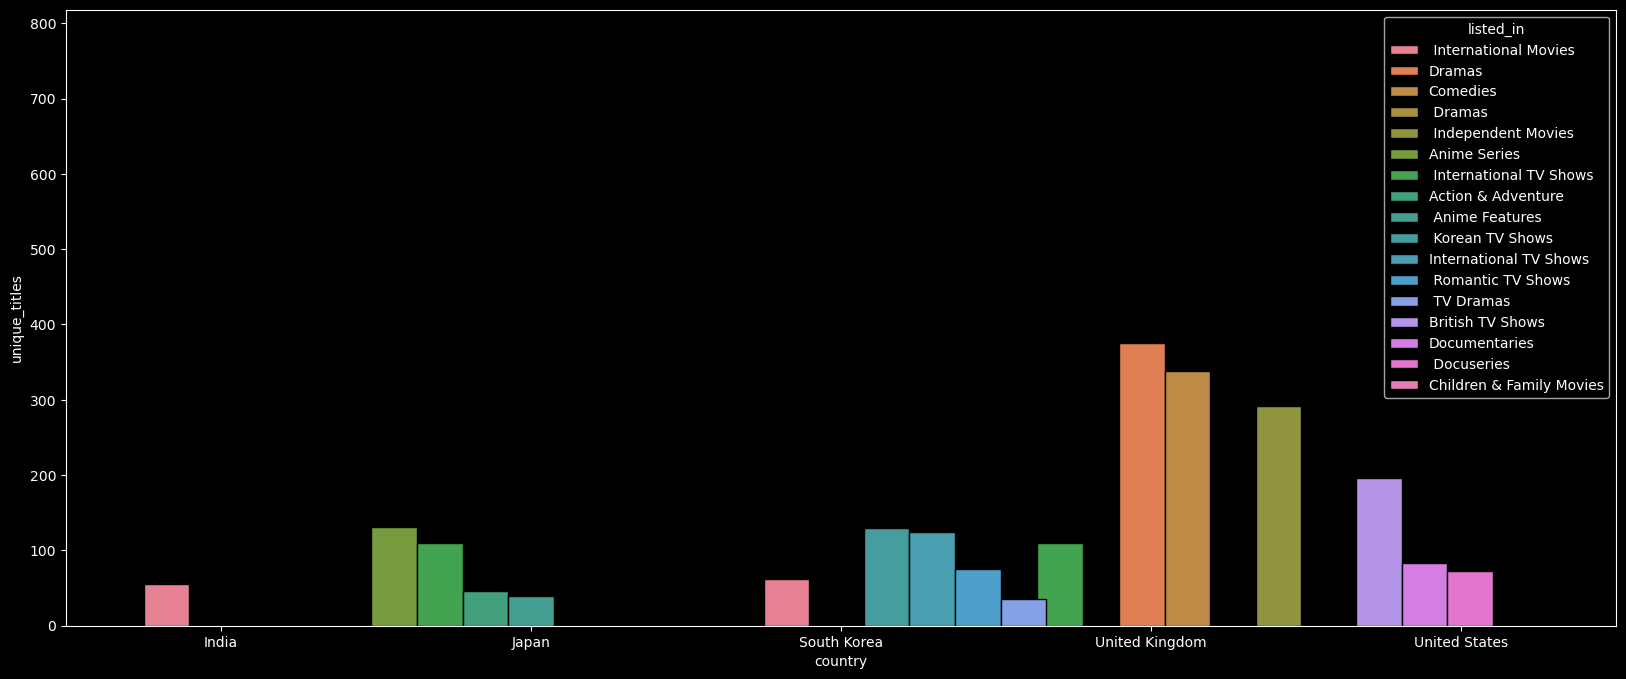

In [273]:
plt.figure(figsize = (20,8))
sns.barplot(data = result,x = 'country',y = 'unique_titles',hue = 'listed_in',edgecolor = 'black',width = 2.5)


In [287]:
temp = split_exp(data,'listed_in')

In [288]:
Japan = temp[temp['country'] == 'Japan']
SK = temp[temp['country'] == 'South Korea']
UK = temp[temp['country'] == 'United Kingdom']

In [289]:
Japan = Japan.groupby('listed_in')['title'].nunique().reset_index().sort_values(by = 'title',ascending = False)[:5]
SK = SK.groupby('listed_in')['title'].nunique().reset_index().sort_values(by = 'title',ascending = False)[:5]
UK = UK.groupby('listed_in')['title'].nunique().reset_index().sort_values(by = 'title',ascending = False)[:5]

In [290]:
Japan

,listed_in,title
26,Anime Series,131
7,International TV Shows,110
6,International Movies,55
24,Action & Adventure,46
0,Anime Features,39


Text(0.5, 1.0, 'United Kingdom')

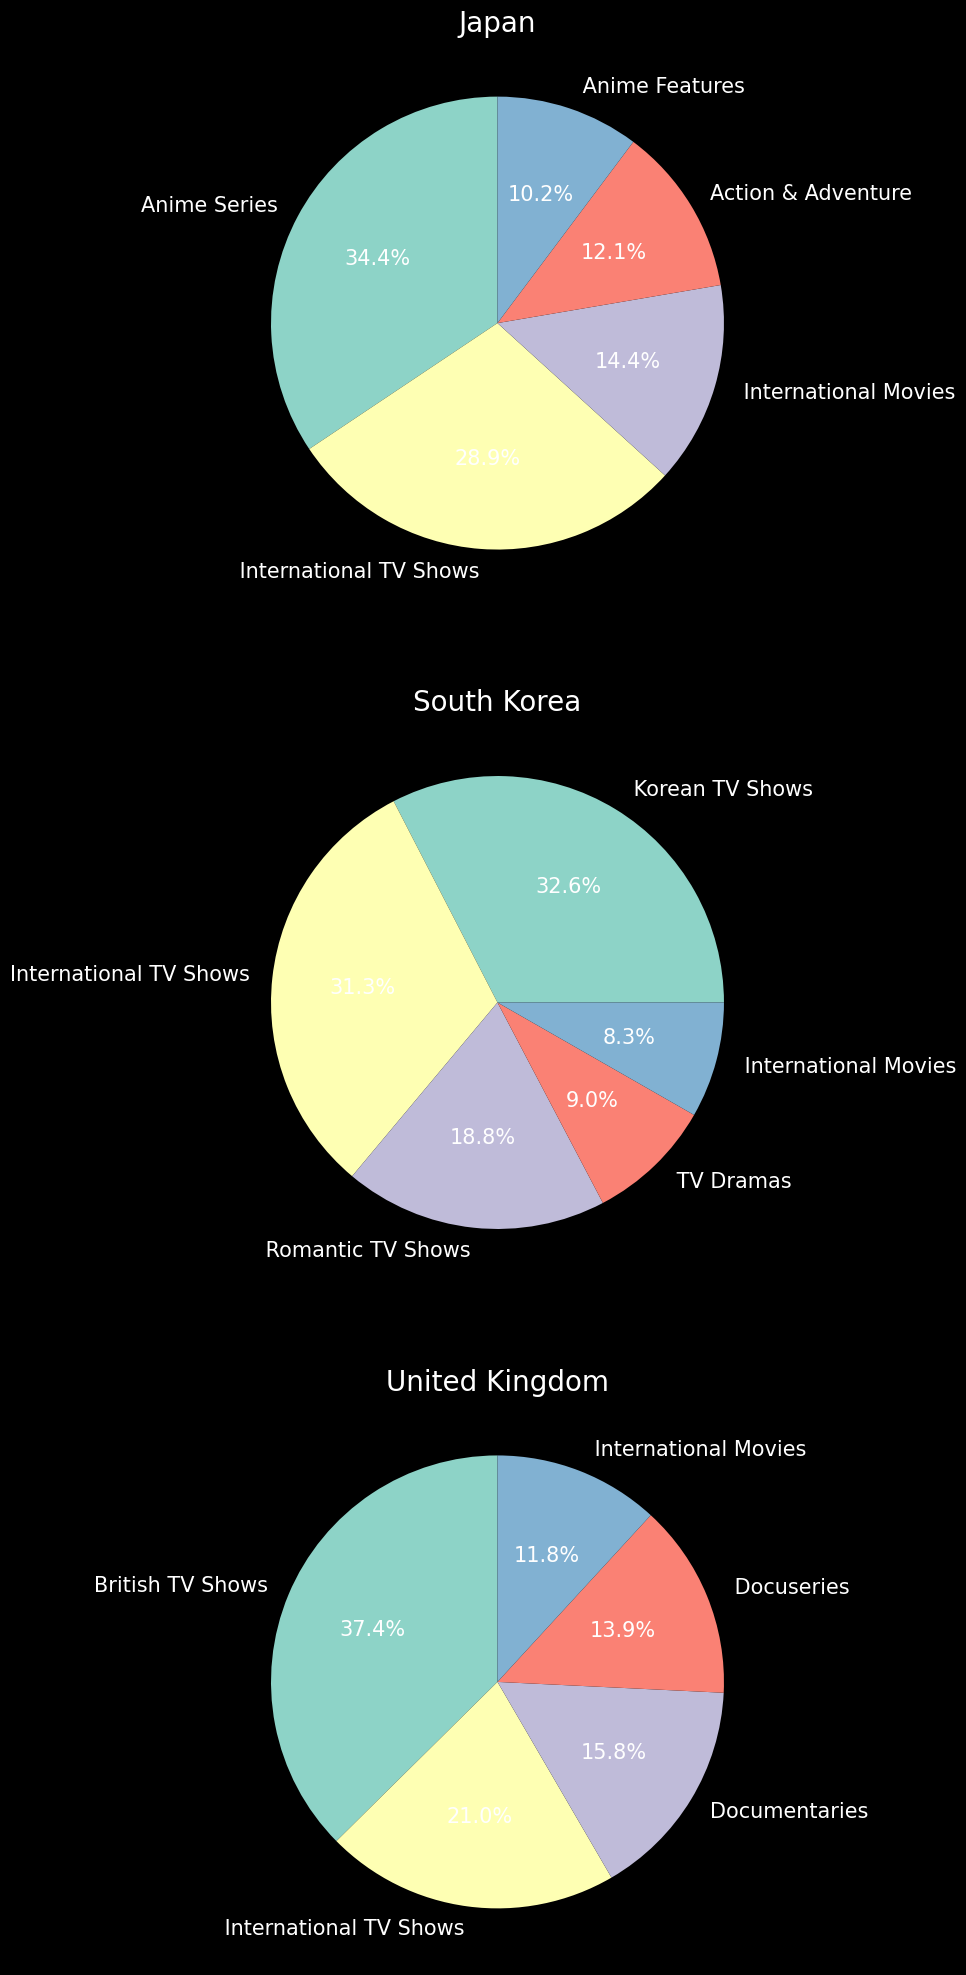

In [313]:
plt.figure(figsize = (25,25))
plt.subplot(3,1,1)
plt.pie(Japan['title'],labels = Japan['listed_in'],startangle = 90,autopct = '%1.1f%%',textprops={'fontsize': 15})
plt.title('Japan',fontsize = 20)
plt.subplot(3,1,2)
plt.pie(SK['title'],labels = SK['listed_in'],autopct = '%1.1f%%',textprops={'fontsize': 15})
plt.title('South Korea',fontsize = 20)
plt.subplot(3,1,3)
plt.pie(UK['title'],labels = UK['listed_in'],startangle = 90,autopct = '%1.1f%%',textprops={'fontsize': 15})
plt.title('United Kingdom',fontsize = 20)


In [346]:
India = temp[temp['country'] == 'India']
USA =  temp[temp['country'] == 'United States']
India = India.groupby('listed_in')['title'].nunique().reset_index().sort_values(by = 'title',ascending = False)[:5]
USA = USA.groupby('listed_in')['title'].nunique().reset_index().sort_values(by = 'title',ascending = False)[:5]

In [347]:
India

,listed_in,title
8,International Movies,779
36,Dramas,384
31,Comedies,262
4,Dramas,236
7,Independent Movies,149


In [348]:
USA

,listed_in,title
45,Documentaries,388
47,Dramas,376
42,Comedies,338
10,Independent Movies,292
39,Children & Family Movies,256


In [349]:
USA['country'] = 'USA'
India['country'] = 'India'

df10 = pd.concat([USA, India], ignore_index=True)


# Pivot so that countries are x-axis and genres are stacked
stacked_data = df10.pivot(index='country', columns='listed_in', values='title').fillna(0)

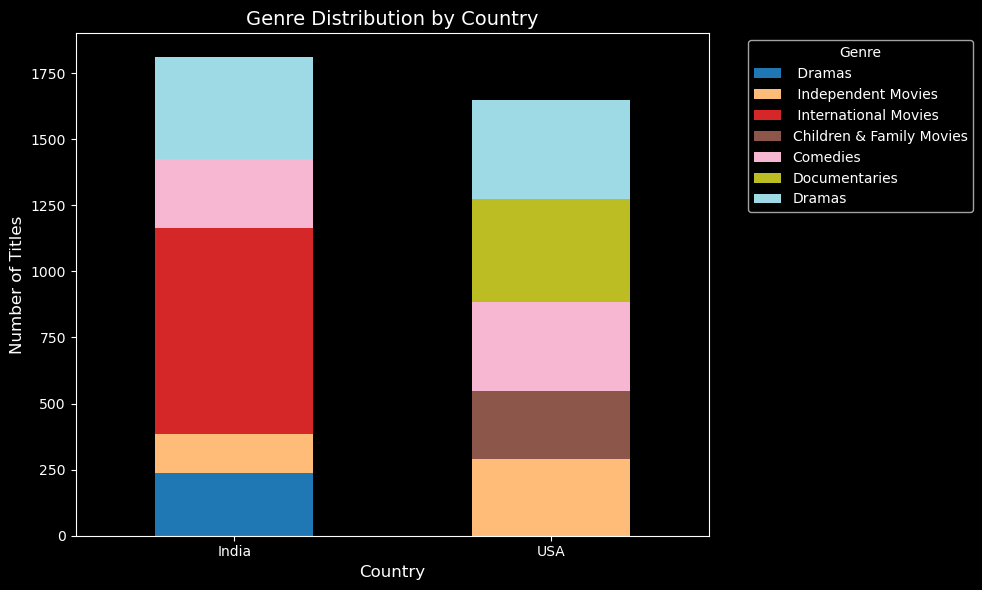

In [350]:
stacked_data.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    cmap='tab20'  # colorful palette for multiple genres
)

plt.title('Genre Distribution by Country', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=0)  # keep country names horizontal
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [345]:
Japan

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unkown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
21,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,Comedies,A woman adjusting to life after a loss contend...
22,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,Dramas,A woman adjusting to life after a loss contend...
36,s16,TV Show,Dear White People,unknown,"Logan Browning, Brandon P. Bell, DeRon Horton,...",United States,"September 22, 2021",2021,TV-MA,4 Seasons,TV Comedies,Students of color navigate the daily slights a...
37,s16,TV Show,Dear White People,unknown,"Logan Browning, Brandon P. Bell, DeRon Horton,...",United States,"September 22, 2021",2021,TV-MA,4 Seasons,TV Dramas,Students of color navigate the daily slights a...
...,...,...,...,...,...,...,...,...,...,...,...,...
19312,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,Thrillers,"A political cartoonist, a crime reporter and a..."
19316,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,Comedies,Looking to survive in a world taken over by zo...
19317,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,Horror Movies,Looking to survive in a world taken over by zo...
19318,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,Children & Family Movies,"Dragged from civilian life, a former superhero..."


In [341]:
stacked_data

listed_in,Independent Movies,Children & Family Movies,Comedies,Documentaries,Dramas
country,,,,,
India,292,256,338,388,376
USA,292,256,338,388,376


In [142]:
temp = split_exp(data,'listed_in')

In [23]:
temp.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unkown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."
2,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t..."
3,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t..."
4,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,"September 24, 2021",2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...


In [122]:
topmovdir = data[(data['type'] == 'Movie')&(data['director']!='unknown')]['director'].value_counts()[:10].reset_index()

In [123]:
topmovdir['type'] = 'Movie'

In [124]:
topmovdir

,director,count,type
0,Rajiv Chilaka,19,Movie
1,"Raúl Campos, Jan Suter",18,Movie
2,Suhas Kadav,16,Movie
3,Marcus Raboy,15,Movie
4,Jay Karas,14,Movie
5,Cathy Garcia-Molina,13,Movie
6,Martin Scorsese,12,Movie
7,Jay Chapman,12,Movie
8,Youssef Chahine,12,Movie
9,Steven Spielberg,11,Movie


In [125]:
topshowdir = data[(data['type'] == 'TV Show')& (data['director']!='unknown')]['director'].value_counts()[:10].reset_index()

In [126]:
topshowdir['type'] = 'TV Show' 

In [127]:
topshowdir

,director,count,type
0,Alastair Fothergill,3,TV Show
1,Rob Seidenglanz,2,TV Show
2,Ken Burns,2,TV Show
3,Stan Lathan,2,TV Show
4,Shin Won-ho,2,TV Show
5,Hsu Fu-chun,2,TV Show
6,Iginio Straffi,2,TV Show
7,Jason Hehir,1,TV Show
8,Gerhard Mostert,1,TV Show
9,"Luis Alfaro, Javier Gómez Santander",1,TV Show


In [128]:
topdir = pd.concat([topmovdir,topshowdir],axis = 0)

In [129]:
topdir

,director,count,type
0,Rajiv Chilaka,19,Movie
1,"Raúl Campos, Jan Suter",18,Movie
2,Suhas Kadav,16,Movie
3,Marcus Raboy,15,Movie
4,Jay Karas,14,Movie
5,Cathy Garcia-Molina,13,Movie
6,Martin Scorsese,12,Movie
7,Jay Chapman,12,Movie
8,Youssef Chahine,12,Movie
9,Steven Spielberg,11,Movie


Text(0.5, 1.0, 'Top 5 directors of TV Show and Movie')

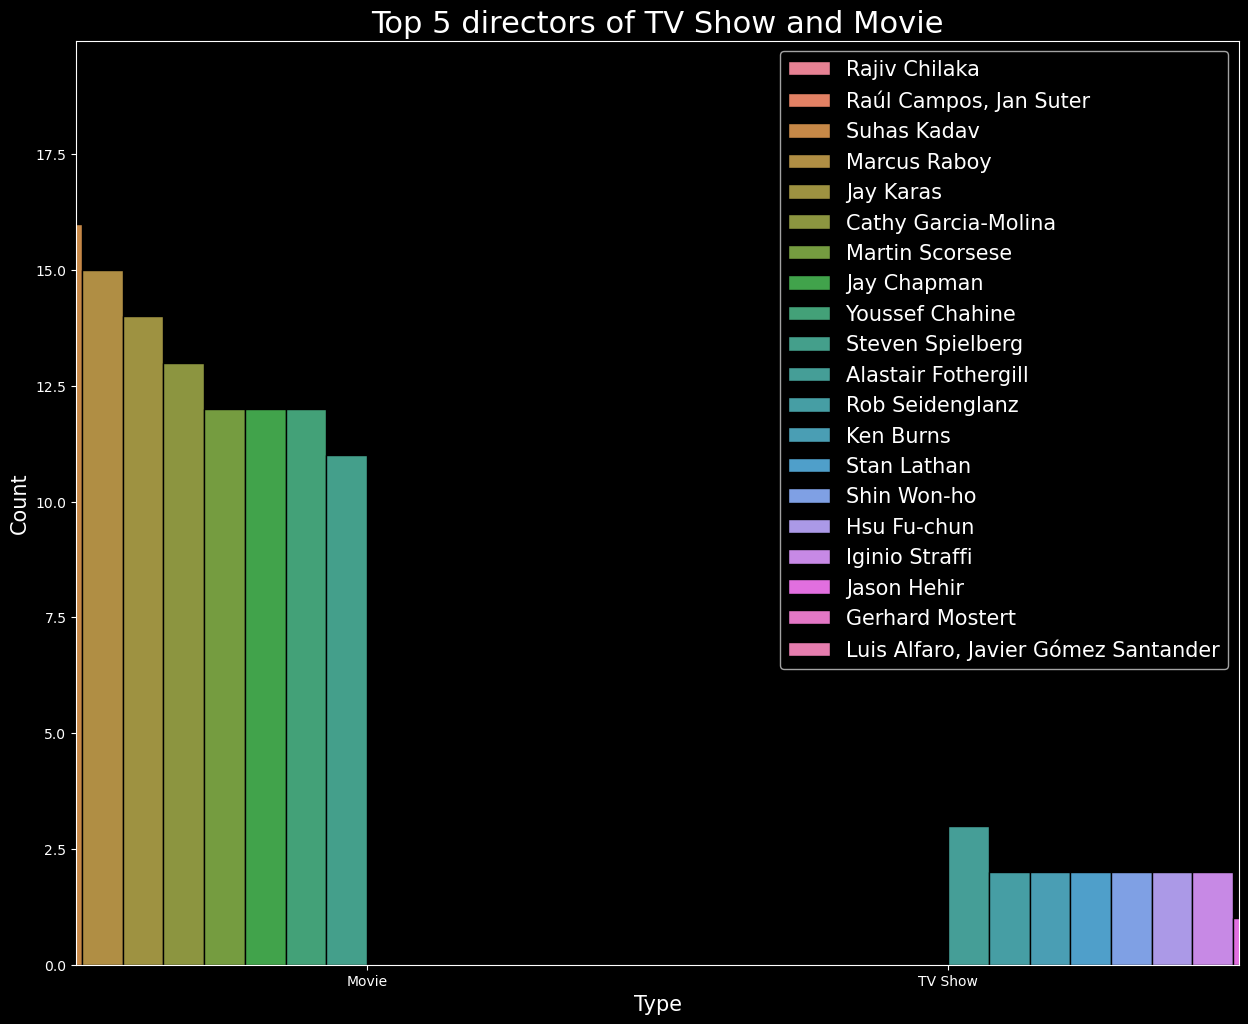

In [137]:
plt.figure(figsize = (15,12))
sns.barplot(data = topdir,x = 'type',y = 'count',hue = 'director',edgecolor = 'black')
plt.style.use('dark_background')
plt.legend(fontsize = 15)
plt.xlabel('Type',fontsize = 15)
plt.ylabel('Count',fontsize = 15)
plt.title('Top 5 directors of TV Show and Movie',fontsize = 22)

In [86]:
temp1 = data[data['director'] != 'unknown']['director'].value_counts().reset_index()[:10]

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Rajiv Chilaka'),
  Text(1, 0, 'Raúl Campos, Jan Suter'),
  Text(2, 0, 'Suhas Kadav'),
  Text(3, 0, 'Marcus Raboy'),
  Text(4, 0, 'Jay Karas'),
  Text(5, 0, 'Cathy Garcia-Molina'),
  Text(6, 0, 'Martin Scorsese'),
  Text(7, 0, 'Youssef Chahine'),
  Text(8, 0, 'Jay Chapman'),
  Text(9, 0, 'Steven Spielberg')])

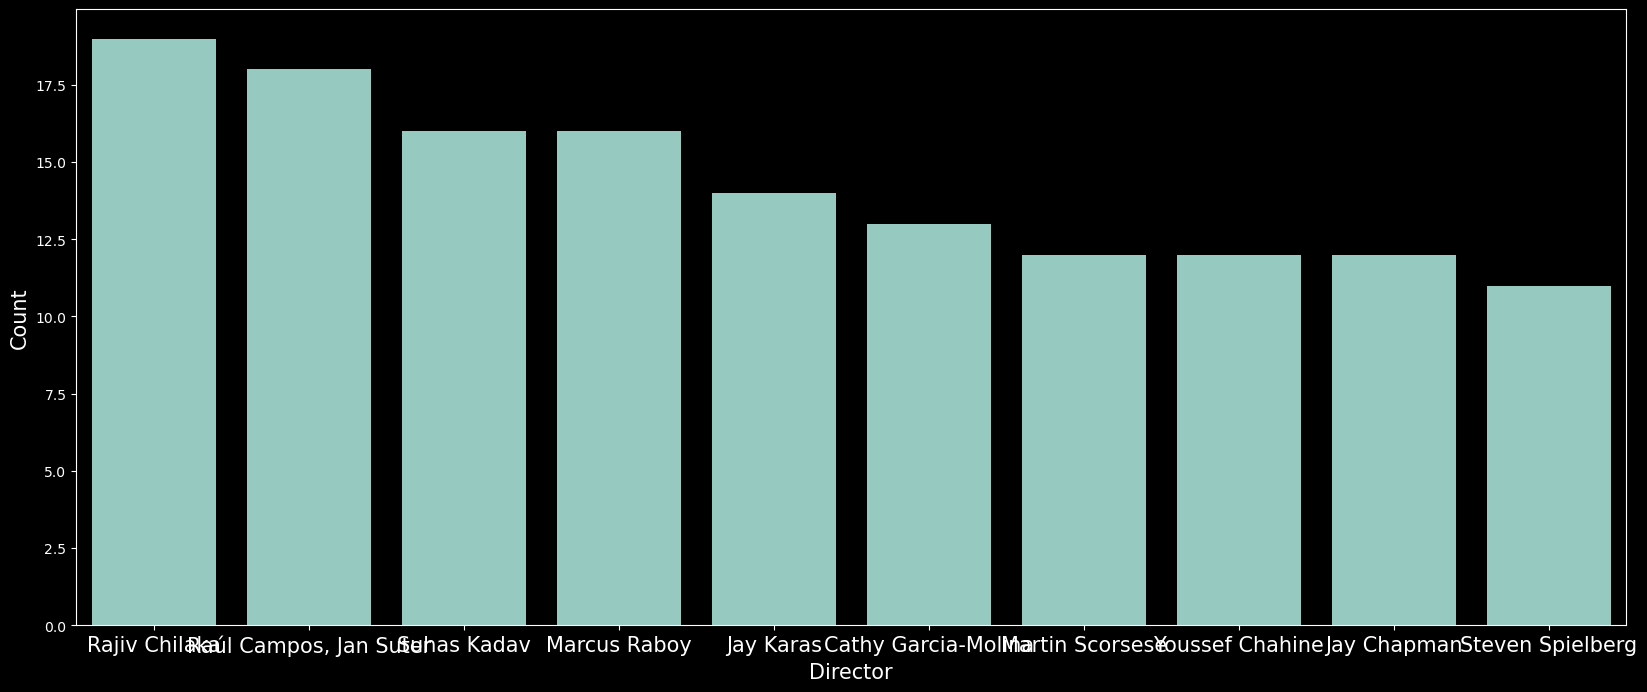

In [95]:
plt.figure(figsize = (2,8))
sns.barplot(data = temp1,x = 'director',y = 'count')
plt.xlabel('Director',fontsize = 15)
plt.ylabel('Count',fontsize = 15)
plt.xticks(fontsize = 15)

In [120]:
temp1.index = np.arange(1,11,1)

In [121]:
temp1

,director,count
1,Rajiv Chilaka,19
2,"Raúl Campos, Jan Suter",18
3,Suhas Kadav,16
4,Marcus Raboy,16
5,Jay Karas,14
6,Cathy Garcia-Molina,13
7,Martin Scorsese,12
8,Youssef Chahine,12
9,Jay Chapman,12
10,Steven Spielberg,11


In [99]:
#•	We will determine productivity on the basis of how many titles have produced per year that is for how many years the director has been active for and how many titles the directors has produced in that duration.
temp2 = data.groupby('director').agg({'release_year':['min','max'],'title':'count'})

In [101]:
temp2.columns = ['yearmin','yearmax','titlecount']

In [104]:
temp2.sort_values(by = 'titlecount',ascending = False,inplace = True)

In [106]:
temp2.reset_index(inplace = True)

In [109]:
temp2 = temp2[temp2['director']!='unknown']

In [ ]:
temp2['years_active'] = temp2['yearmax']-temp2['yearmin']

In [111]:
temp2

,director,yearmin,yearmax,titlecount,years_active
1,Rajiv Chilaka,2009,2018,19,9
2,"Raúl Campos, Jan Suter",2016,2018,18,2
3,Marcus Raboy,2012,2020,16,8
4,Suhas Kadav,2013,2019,16,6
5,Jay Karas,2012,2020,14,8
...,...,...,...,...,...
4524,Álvaro Delgado-Aparicio L.,2017,2017,1,0
4525,Álvaro Brechner,2018,2018,1,0
4526,Zuko Nodada,2019,2019,1,0
4527,Zsolt Pálfi,2019,2019,1,0


In [ ]:
temp2['Productivity'] = temp2['titlecount']/temp2['years_active']

In [114]:
temp2[:10]

,director,yearmin,yearmax,titlecount,years_active,Productivity
1,Rajiv Chilaka,2009,2018,19,9,2.111111
2,"Raúl Campos, Jan Suter",2016,2018,18,2,9.000000
3,Marcus Raboy,2012,2020,16,8,2.000000
4,Suhas Kadav,2013,2019,16,6,2.666667
5,Jay Karas,2012,2020,14,8,1.750000
6,Cathy Garcia-Molina,2008,2019,13,11,1.181818
7,Martin Scorsese,1967,2019,12,52,0.230769
8,Jay Chapman,2012,2018,12,6,2.000000
9,Youssef Chahine,1954,1999,12,45,0.266667
10,Steven Spielberg,1975,2016,11,41,0.268293


In [116]:
temp2[['director','titlecount','years_active','Productivity']][:10]

,director,titlecount,years_active,Productivity
1,Rajiv Chilaka,19,9,2.111111
2,"Raúl Campos, Jan Suter",18,2,9.000000
3,Marcus Raboy,16,8,2.000000
4,Suhas Kadav,16,6,2.666667
5,Jay Karas,14,8,1.750000
6,Cathy Garcia-Molina,13,11,1.181818
7,Martin Scorsese,12,52,0.230769
8,Jay Chapman,12,6,2.000000
9,Youssef Chahine,12,45,0.266667
10,Steven Spielberg,11,41,0.268293


In [172]:
temp4 = temp.groupby(['director','listed_in'])['title'].nunique().reset_index()
temp4 = temp4[temp4['director']!='unknown']

In [173]:
temp4.sort_values(by = 'title',ascending = False,inplace = True)

In [174]:
temp4.head()

,director,listed_in,title
8269,Rajiv Chilaka,Children & Family Movies,19
8401,"Raúl Campos, Jan Suter",Stand-Up Comedy,18
9948,Suhas Kadav,Children & Family Movies,16
6281,Marcus Raboy,Stand-Up Comedy,15
4339,Jay Karas,Stand-Up Comedy,13


In [175]:
list(temp2['director'][:10])

['Rajiv Chilaka',
 'Raúl Campos, Jan Suter',
 'Marcus Raboy',
 'Suhas Kadav',
 'Jay Karas',
 'Cathy Garcia-Molina',
 'Martin Scorsese',
 'Jay Chapman',
 'Youssef Chahine',
 'Steven Spielberg']

In [176]:
temp4 = temp4[temp4['director'].isin(list(temp2['director'][:10]))]

In [177]:
temp4

,director,listed_in,title
8269,Rajiv Chilaka,Children & Family Movies,19
8401,"Raúl Campos, Jan Suter",Stand-Up Comedy,18
9948,Suhas Kadav,Children & Family Movies,16
6281,Marcus Raboy,Stand-Up Comedy,15
4339,Jay Karas,Stand-Up Comedy,13
1694,Cathy Garcia-Molina,International Movies,11
4330,Jay Chapman,Stand-Up Comedy,11
11045,Youssef Chahine,International Movies,10
1695,Cathy Garcia-Molina,Romantic Movies,8
9946,Suhas Kadav,Comedies,8


In [178]:
temp4

,director,listed_in,title
8269,Rajiv Chilaka,Children & Family Movies,19
8401,"Raúl Campos, Jan Suter",Stand-Up Comedy,18
9948,Suhas Kadav,Children & Family Movies,16
6281,Marcus Raboy,Stand-Up Comedy,15
4339,Jay Karas,Stand-Up Comedy,13
1694,Cathy Garcia-Molina,International Movies,11
4330,Jay Chapman,Stand-Up Comedy,11
11045,Youssef Chahine,International Movies,10
1695,Cathy Garcia-Molina,Romantic Movies,8
9946,Suhas Kadav,Comedies,8


In [182]:
temptest = temp4.pivot(index = 'director',columns = 'listed_in',values = 'title')

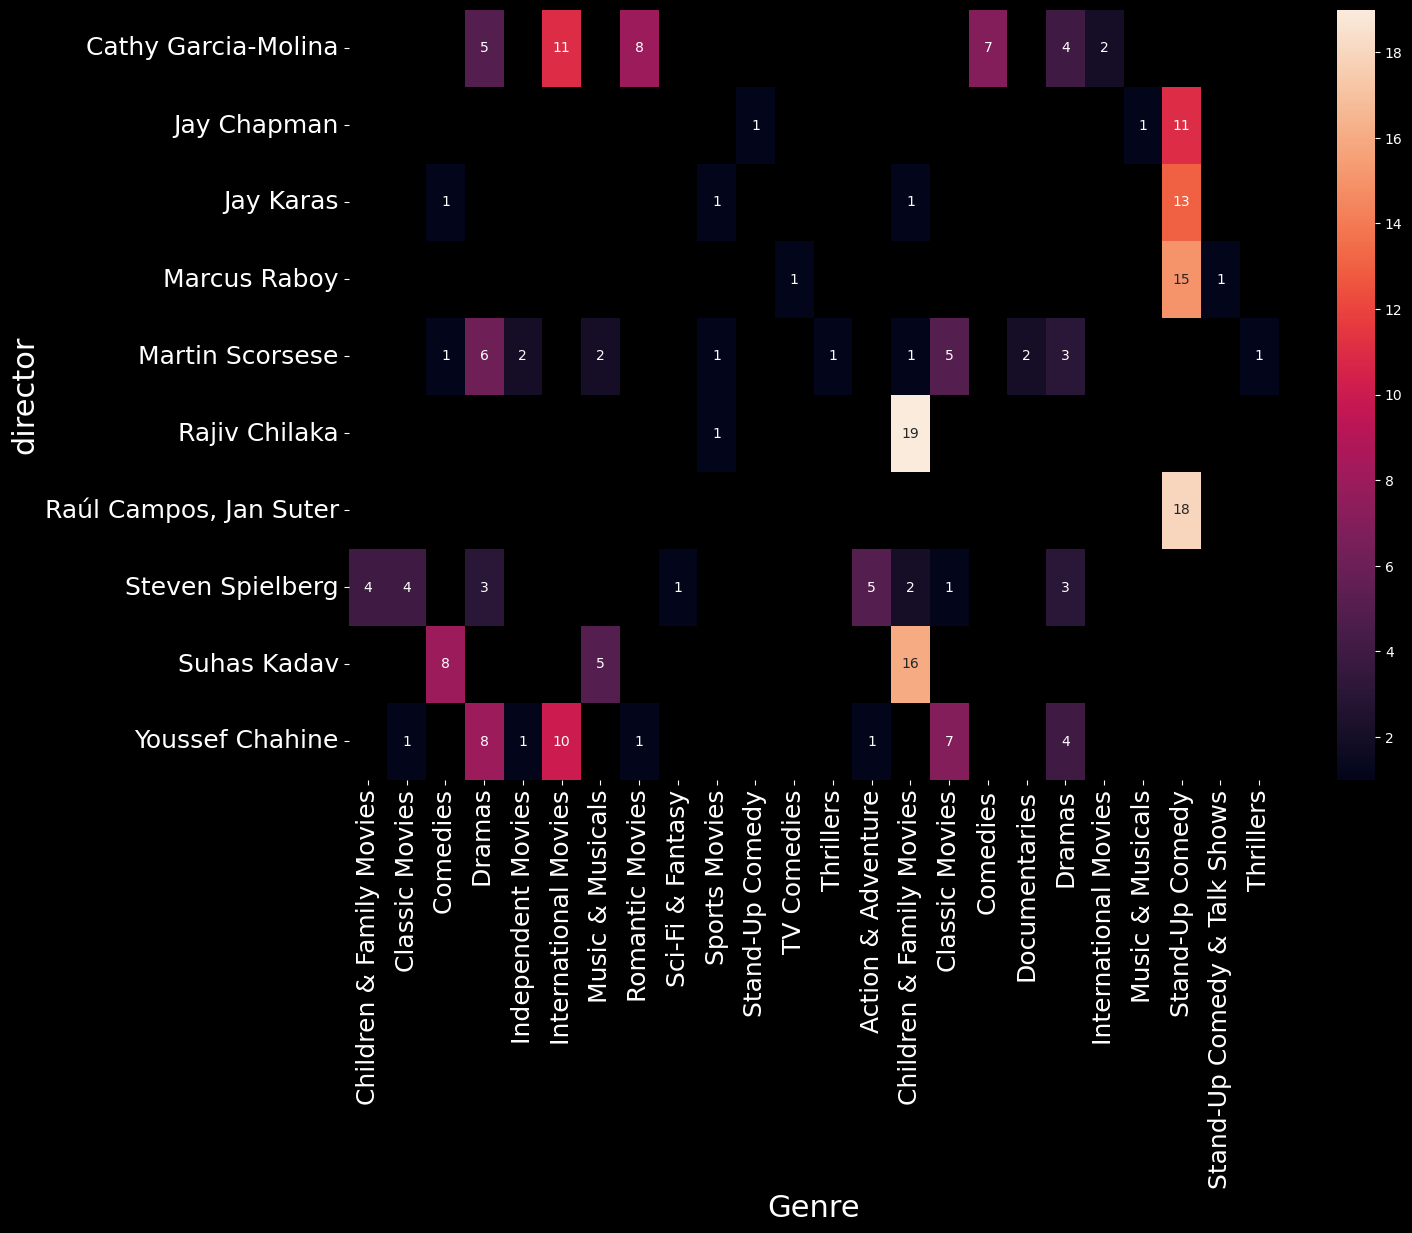

In [193]:
plt.figure(figsize = (15,10))
sns.heatmap(temptest,annot = True)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.xlabel('Genre',fontsize = 22)
plt.ylabel('director',fontsize = 22)
plt.show()

In [227]:
test1 = split_exp(data,'cast')
test1 = test1[test1['cast'] != 'unkown']

In [228]:
test1 = test1.groupby('cast')['title'].nunique().reset_index().sort_values(by = 'title',ascending = False)[:10]
test1.columns = ['Actor','Total titles']
test1

,Actor,Total titles
2612,Anupam Kher,39
26941,Rupa Bhimani,31
30303,Takahiro Sakurai,30
15541,Julie Tejwani,28
23624,Om Puri,27
38445,Shah Rukh Khan,26
25410,Rajesh Kava,26
23956,Paresh Rawal,25
1905,Andrea Libman,25
33367,Yuki Kaji,25


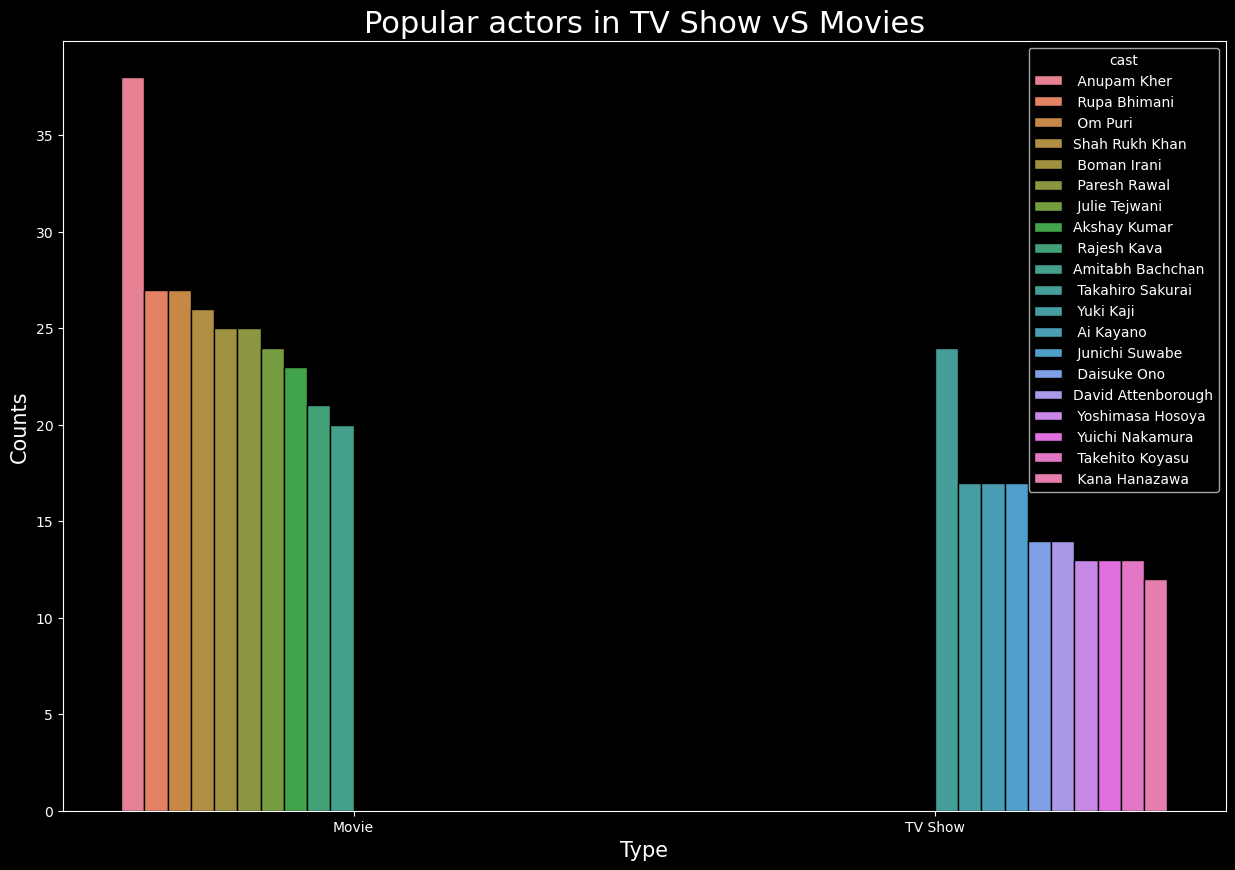

In [240]:
test2 = split_exp(data,'cast')
test2 = test2[(test2['cast'] != 'unkown')&(test2['type'] == 'Movie')]
test2 = test2.groupby('cast')['title'].nunique().reset_index().sort_values(by = 'title',ascending = False)[:10]
test3 = split_exp(data,'cast')
test3 = test3[(test3['cast'] != 'unkown')&(test3['type'] == 'TV Show')]
test3 = test3.groupby('cast')['title'].nunique().reset_index().sort_values(by = 'title',ascending = False)[:10]
test2['type'] = 'Movie'
test3['type'] = 'TV Show'
test4 = pd.concat([test2,test3],axis = 0)
test4
plt.figure(figsize = (15,10))
sns.barplot(data = test4,x = 'type',y ='title',hue = 'cast',edgecolor = 'black') 
plt.xlabel('Type',fontsize = 15)
plt.ylabel('Counts',fontsize = 15)
plt.title('Popular actors in TV Show vS Movies',fontsize = 22)
plt.show()

In [241]:
test4 

,cast,title,type
1946,Anupam Kher,38,Movie
19235,Rupa Bhimani,27,Movie
16781,Om Puri,27,Movie
27291,Shah Rukh Khan,26,Movie
3109,Boman Irani,25,Movie
17025,Paresh Rawal,25,Movie
11219,Julie Tejwani,24,Movie
24247,Akshay Kumar,23,Movie
18089,Rajesh Kava,21,Movie
24332,Amitabh Bachchan,20,Movie


In [245]:
var = data.groupby('rating')['title'].nunique().reset_index()

In [246]:
var.head()

,rating,title
0,0,4
1,66 min,1
2,74 min,1
3,84 min,1
4,G,41


In [250]:
var.drop([0,1,2,3],inplace = True)

In [252]:
var.reset_index(inplace = True,drop = True)

In [255]:
var.sort_values(by = 'title',ascending = False,inplace = True)

In [256]:
var

,rating,title
8,TV-MA,3207
6,TV-14,2160
9,TV-PG,863
5,R,799
4,PG-13,490
11,TV-Y7,334
10,TV-Y,307
3,PG,287
7,TV-G,220
2,NR,80


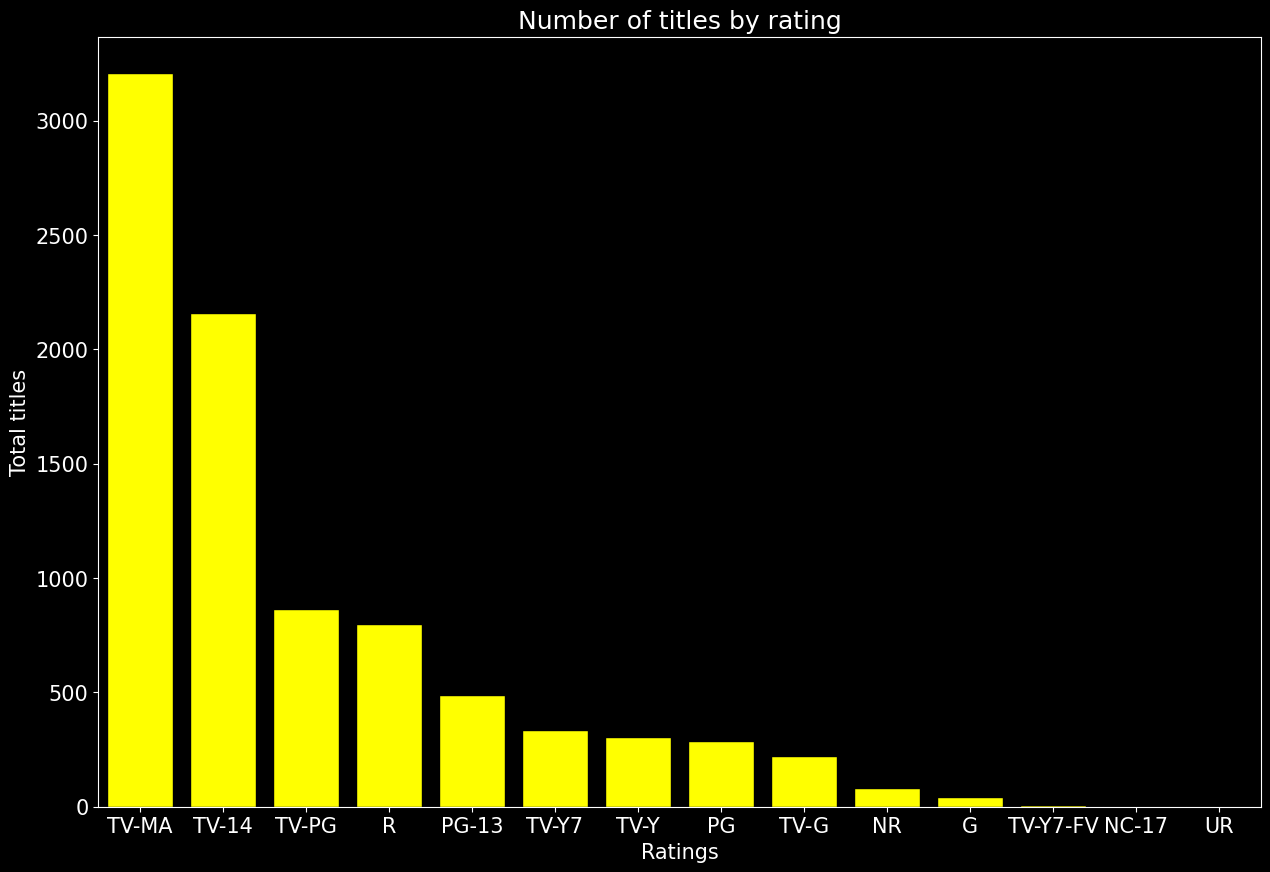

In [266]:
plt.figure(figsize = (15,10))
sns.barplot(data = var,x = 'rating',y = 'title',edgecolor = 'black',facecolor = 'yellow')
plt.title('Number of titles by rating',fontsize = 18)
plt.xlabel('Ratings',fontsize = 15)
plt.ylabel('Total titles',fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()